In [24]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

lr_model = joblib.load("../B. ML & Analytics/models/logistic_model.pkl")
scaler = joblib.load("../B. ML & Analytics/models/scaler.pkl")
df = pd.read_csv("../A. Data Pipeline/Data/gold/risk_feature_store.csv")

X = df.drop(columns=["is_denied"]).select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

print(f"Model loaded")
print(f"Data: {X.shape}")

C:\Users\KhaiH\AppData\Local\Temp\ipykernel_30832\828964164.py:8: DtypeWarning: Columns (0: total_units) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../A. Data Pipeline/Data/gold/risk_feature_store.csv")


Model loaded
Data: (2775524, 38)


In [25]:
scenarios = {
    "Baseline (Current)": {},
    "Mild Recession": {
        "income": -0.10,              
        "debt_to_income_ratio": +0.15, 
        "loan_to_income": +0.15,
    },
    "Severe Recession": {
        "income": -0.25,              
        "debt_to_income_ratio": +0.35, 
        "loan_to_income": +0.40,
        "loan_amount": +0.10,
    },
    "2008-like Housing Crisis": {
        "income": -0.40,              
        "debt_to_income_ratio": +0.60, 
        "loan_to_income": +0.80,
        "loan_amount": +0.20,
        "property_value": -0.30,      
    },
}

print(f"{len(scenarios)} scenarios defined")

4 scenarios defined


In [26]:
results = []
for name, shocks in scenarios.items():
    X_stress = X.copy()
    for feature, pct in shocks.items():
        if feature in X_stress.columns:
            X_stress[feature] = X_stress[feature] * (1 + pct)

    X_stress_scaled = scaler.transform(X_stress)
    pd_predictions = lr_model.predict_proba(X_stress_scaled)[:, 1]

    results.append({
        "Scenario": name,
        "Mean PD (%)": round(pd_predictions.mean() * 100, 2),
        "Median PD (%)": round(np.median(pd_predictions) * 100, 2),
        "PD > 50% (%)": round((pd_predictions > 0.5).mean() * 100, 2),
        "Expected Loss (LGD=45%)": round(pd_predictions.mean() * 0.45 * 100, 2),
    })
    
stress_df = pd.DataFrame(results)
print(stress_df.to_string(index=False))

                Scenario  Mean PD (%)  Median PD (%)  PD > 50% (%)  Expected Loss (LGD=45%)
      Baseline (Current)        45.28          41.16         41.24                    20.38
          Mild Recession        70.16          71.02         85.85                    31.57
        Severe Recession        91.07          92.88         99.92                    40.98
2008-like Housing Crisis        98.61          99.09         99.98                    44.38


In [27]:
print("=" * 70)
print("STRESS TEST RESULTS")
print("=" * 70)
print(stress_df.to_string(index=False))

STRESS TEST RESULTS
                Scenario  Mean PD (%)  Median PD (%)  PD > 50% (%)  Expected Loss (LGD=45%)
      Baseline (Current)        45.28          41.16         41.24                    20.38
          Mild Recession        70.16          71.02         85.85                    31.57
        Severe Recession        91.07          92.88         99.92                    40.98
2008-like Housing Crisis        98.61          99.09         99.98                    44.38


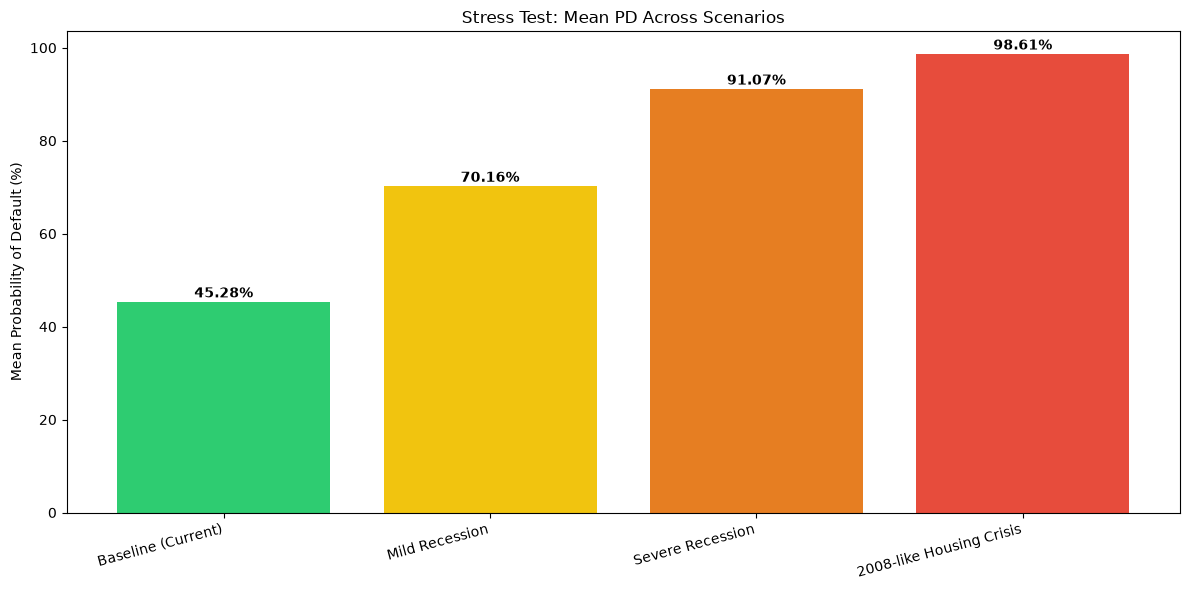

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(stress_df))
bars = ax.bar(x, stress_df["Mean PD (%)"], color=["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"])
ax.set_xticks(x)
ax.set_xticklabels(stress_df["Scenario"], rotation=15, ha="right")
ax.set_ylabel("Mean Probability of Default (%)")
ax.set_title("Stress Test: Mean PD Across Scenarios")

for bar, val in zip(bars, stress_df["Mean PD (%)"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.2f}%", ha="center", va="bottom", fontweight="bold")
    
plt.tight_layout()
plt.savefig("../B. ML & Analytics/dashboard/stress_test_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
stress_df.to_csv("../A. Data Pipeline/Data/gold/stress_test_results.csv", index=False)
print("Stress test results saved.")

Stress test results saved.
